In [1]:
import os

# Ruta base del proyecto
base_dir = r"C:\Users\paola\Analisis Geoespacial\Proyecto_01 - copia"

# Carpeta para guardar gráficos
graficos_dir = os.path.join(base_dir, "Graficos_Articulo")
os.makedirs(graficos_dir, exist_ok=True)


In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Cargar datos
ruta = r"C:\Users\paola\Analisis Geoespacial\Proyecto_01 - copia\Datos de cultivos\Precipitacion_promedio_semestre_Meta_Casanare_2013_2023.csv"
df = pd.read_csv(ruta)

# Asegurar tipos correctos
df['year'] = df['year'].astype(int)
df['sem'] = df['semester'].str.extract(r'(\d)').astype(int)

# Crear carpeta de salida
base_dir = r"C:\Users\paola\Analisis Geoespacial\Proyecto_01 - copia"
graficos_dir = os.path.join(base_dir, "Graficos_Articulo")
os.makedirs(graficos_dir, exist_ok=True)


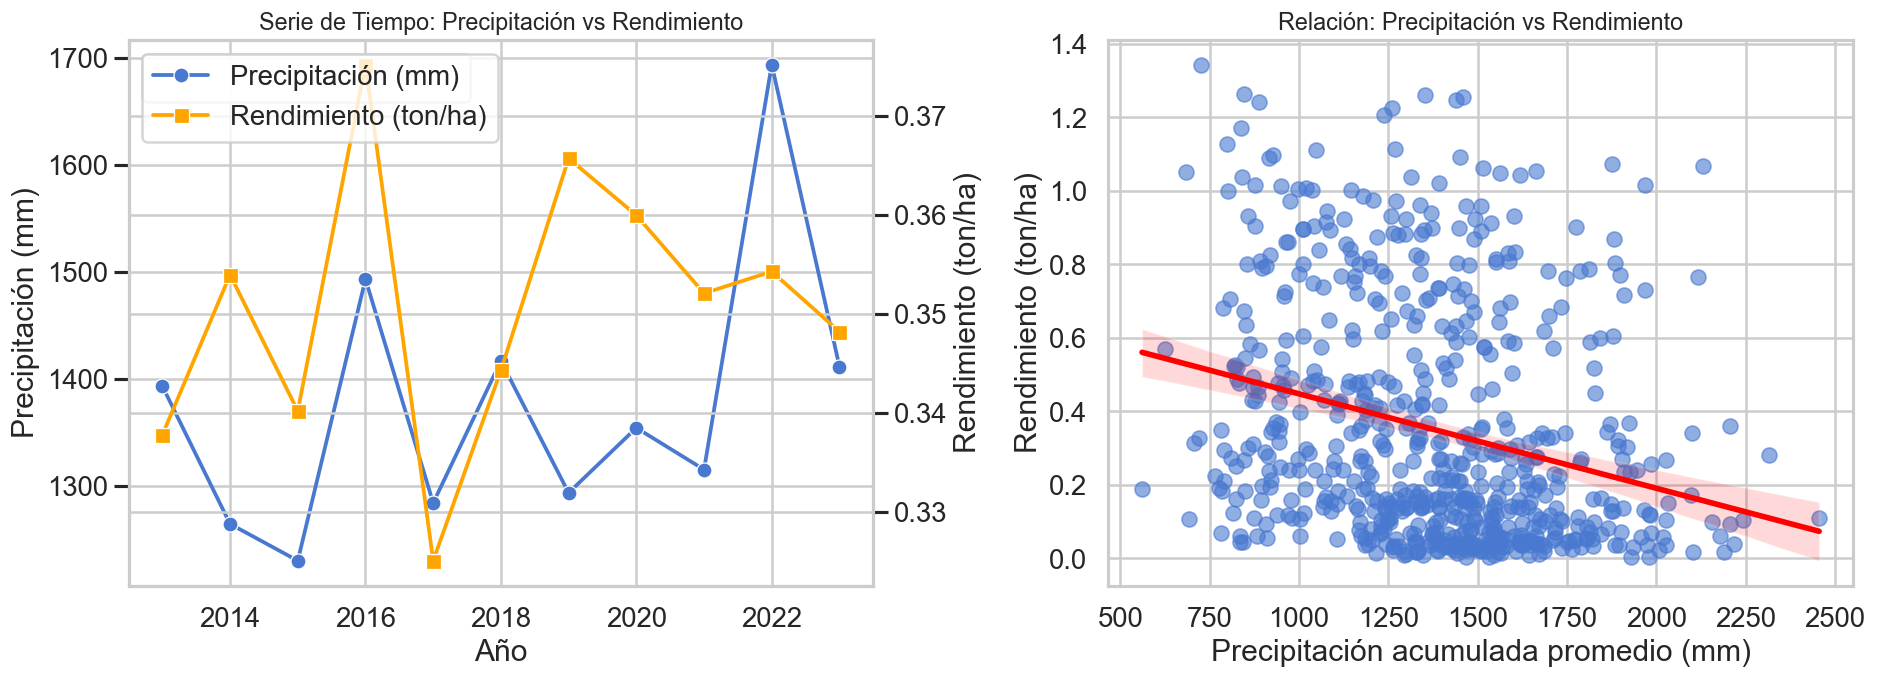

In [29]:
# --- Importar librerías ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- Configurar estilo de los gráficos ---
sns.set(style="whitegrid", context="talk", palette="muted")

# --- Cargar la base de datos ---
ruta = r"C:\Users\paola\Analisis Geoespacial\Proyecto_01 - copia\Datos de cultivos\BaseDatosArroz_con_precipitacion_alta_con_coords.xlsx"
df = pd.read_excel(ruta)

# --- Limpieza de columnas: quitar espacios, normalizar ---
df.columns = df.columns.str.strip().str.replace(" ", "_")

# --- Filtrar valores nulos en variables clave ---
df = df.dropna(subset=['year_GEE', 'precip_accum_avg_mm', 'Rend'])

# --- Agrupar por año: promedio de precipitación y rendimiento ---
df_grouped = df.groupby('year_GEE').agg({
    'precip_accum_avg_mm': 'mean',
    'Rend': 'mean'
}).reset_index()

# --- Crear figura con 1 fila y 2 columnas ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Subgráfico 1: Series de tiempo comparadas ---
ax1 = axes[0]
sns.lineplot(data=df_grouped, x='year_GEE', y='precip_accum_avg_mm', label='Precipitación (mm)', marker='o', ax=ax1)
ax2 = ax1.twinx()
sns.lineplot(data=df_grouped, x='year_GEE', y='Rend', label='Rendimiento (ton/ha)', marker='s', ax=ax2, color='orange')

ax1.set_title("Serie de Tiempo: Precipitación vs Rendimiento", fontsize=14)
ax1.set_xlabel("Año")
ax1.set_ylabel("Precipitación (mm)")
ax2.set_ylabel("Rendimiento (ton/ha)")
ax1.grid(True)

# Leyenda combinada
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax2.legend(h1 + h2, l1 + l2, loc='upper left')

# --- Subgráfico 2: Dispersión Precipitación vs Rendimiento ---
sns.regplot(data=df, x='precip_accum_avg_mm', y='Rend', scatter_kws={'alpha':0.6}, line_kws={"color":"red"}, ax=axes[1])
axes[1].set_title("Relación: Precipitación vs Rendimiento", fontsize=14)
axes[1].set_xlabel("Precipitación acumulada promedio (mm)")
axes[1].set_ylabel("Rendimiento (ton/ha)")

# --- Ajustar diseño ---
plt.tight_layout()

# --- Guardar gráfico ---
ruta_guardado = r"C:\Users\paola\Analisis Geoespacial\Proyecto_01 - copia\Graficos_Articulo\precipitacion_vs_rendimiento.png"
plt.savefig(ruta_guardado, dpi=300)

# --- Mostrar gráfico ---
plt.show()


C:\Users\paola\AppData\Local\Temp\ipykernel_2540\3401625683.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Departamento', y='Rend', data=df, palette='Set2', ax=axs[0])


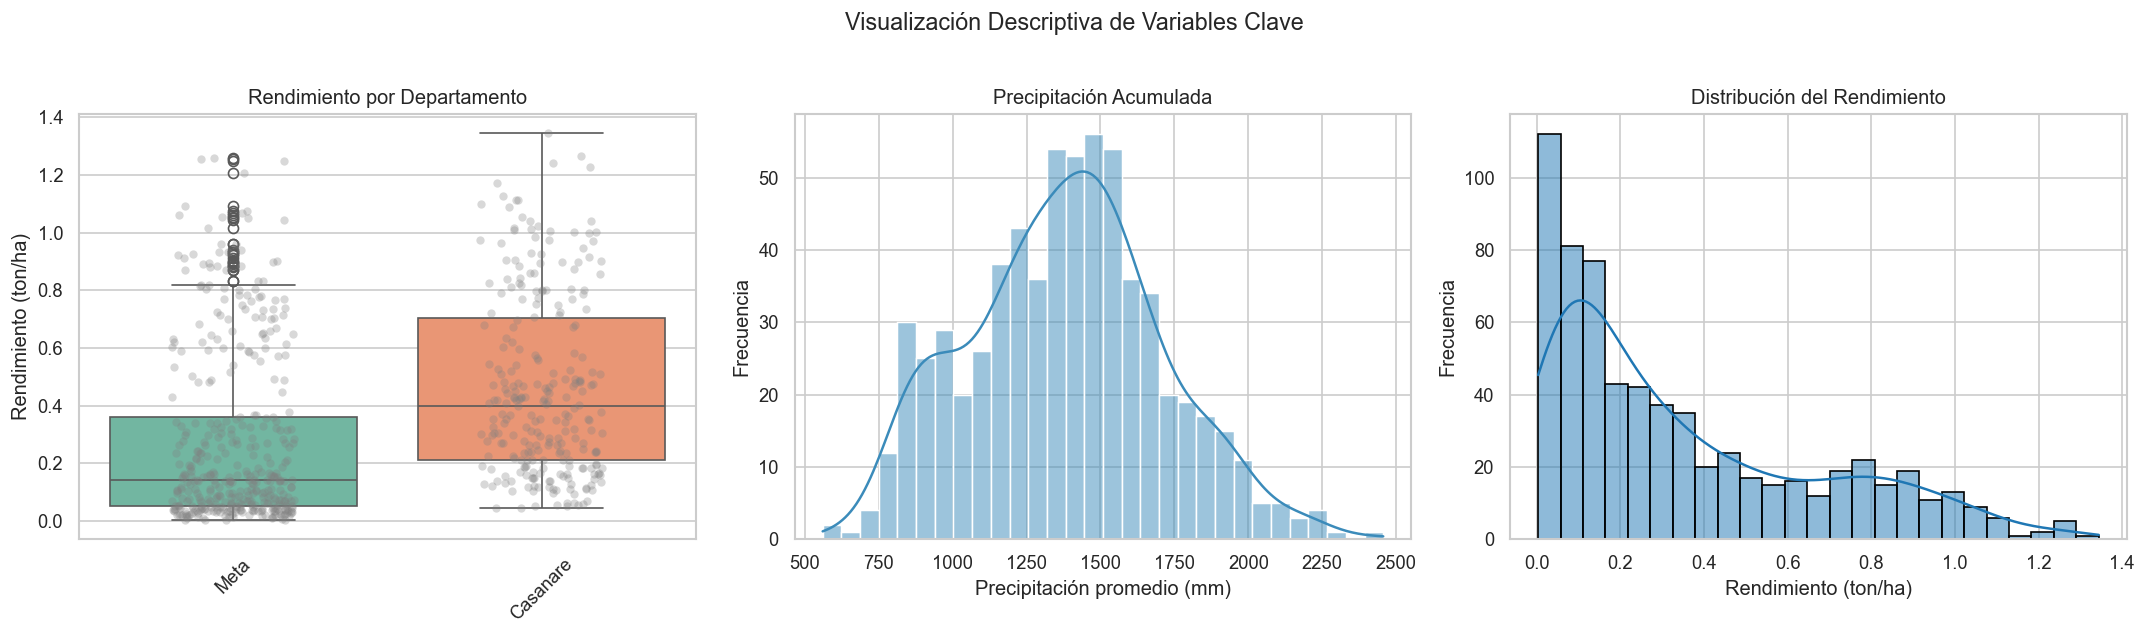

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from shapely.geometry import Point

# Estilo general
sns.set(style='whitegrid')
plt.rcParams.update({'font.size': 10})

# Crear geometría de puntos
df['geometry'] = df.apply(lambda row: Point(row['lon'], row['lat']), axis=1)
gdf = gpd.GeoDataFrame(df, geometry='geometry')
gdf.set_crs("EPSG:4326", inplace=True)

# Crear variable de periodo
df['periodo'] = df['Año'].astype(str) + 'S' + df['Semestre'].astype(str)
serie = df.groupby('periodo')['Rend'].mean().reset_index()

# Crear figura en una sola fila con tres columnas
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Visualización Descriptiva de Variables Clave', fontsize=14, y=1.05)

# Gráfico 1: Boxplot del rendimiento por departamento
sns.boxplot(x='Departamento', y='Rend', data=df, palette='Set2', ax=axs[0])
sns.stripplot(x='Departamento', y='Rend', data=df, color='gray', alpha=0.3, jitter=0.2, ax=axs[0])
axs[0].set_title('Rendimiento por Departamento')
axs[0].set_xlabel('')
axs[0].set_ylabel('Rendimiento (ton/ha)')
axs[0].tick_params(axis='x', rotation=45)

# Gráfico 2: Histograma de precipitación acumulada
sns.histplot(df['precip_accum_avg_mm'], kde=True, bins=30, color='#3b8bba', ax=axs[1])
axs[1].set_title('Precipitación Acumulada')
axs[1].set_xlabel('Precipitación promedio (mm)')
axs[1].set_ylabel('Frecuencia')

# Gráfico 3: Histograma del rendimiento
sns.histplot(data=df, x='Rend', bins=25, kde=True, color='#1f77b4', edgecolor='black', ax=axs[2])
axs[2].set_title('Distribución del Rendimiento')
axs[2].set_xlabel('Rendimiento (ton/ha)')
axs[2].set_ylabel('Frecuencia')

plt.tight_layout()
plt.subplots_adjust(top=0.88)
fig.savefig(r"C:\Users\paola\Analisis Geoespacial\Proyecto_01 - copia\Graficos_Articulo\figura_analisis_descriptivo.png", dpi=300, bbox_inches='tight')

plt.show()


Columnas disponibles: Index(['Departamento', 'Area', 'Rend', 'Año', 'Semestre', 'Rend_Cuartil',
       'Bajo_Rendimiento', 'municipio_norm', 'semester_GEE', 'year_GEE',
       'precip_accum_avg_mm', 'municipio_fao', 'precipitacion_alta', 'lat',
       'lon', 'geometry'],
      dtype='object')


<Figure size 1200x960 with 0 Axes>

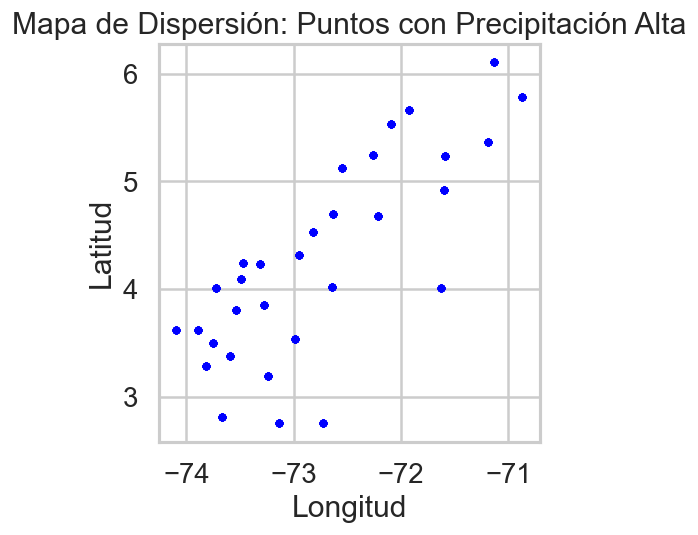

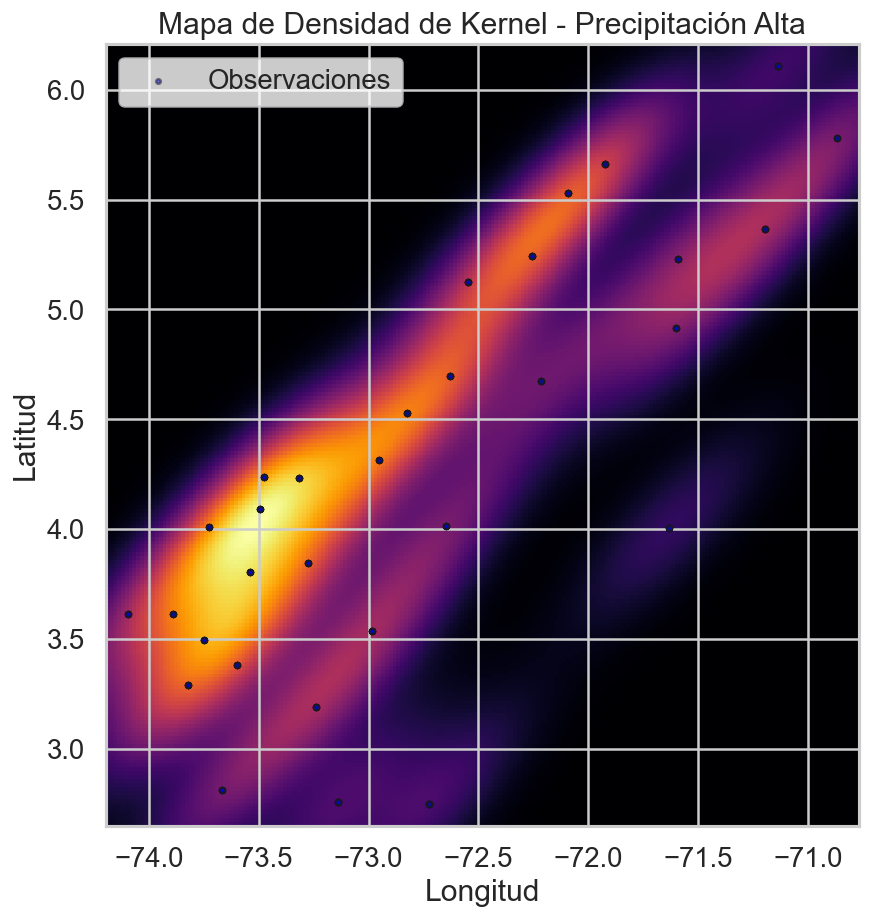

In [31]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from shapely.geometry import Point
from scipy.stats import gaussian_kde
import numpy as np

# --- Leer archivo Excel con coordenadas ---
ruta_excel = r"C:\Users\paola\Analisis Geoespacial\Proyecto_01 - copia\Datos de cultivos\BaseDatosArroz_con_precipitacion_alta_con_coords.xlsx"
df = pd.read_excel(ruta_excel)

# --- Verifica si hay columnas necesarias ---
print("Columnas disponibles:", df.columns)

# --- Crear geometría con latitud y longitud ---
geometry = [Point(xy) for xy in zip(df['lon'], df['lat'])]
gdf = gpd.GeoDataFrame(df, geometry=geometry, crs='EPSG:4326')

# --- Gráfico 1: Mapa de dispersión de puntos ---
plt.figure(figsize=(10, 8))
gdf.plot(marker='o', color='blue', markersize=10, alpha=0.6)
plt.title('Mapa de Dispersión: Puntos con Precipitación Alta')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.grid(True)
plt.tight_layout()
plt.savefig(r"C:\Users\paola\Analisis Geoespacial\Proyecto_01 - copia\Graficos_Articulo\mapa_dispersion.png", dpi=300)
plt.show()

# --- Gráfico 2: Mapa de Densidad de Kernel ---
# Extraer coordenadas
x = df['lon']
y = df['lat']

# Crear malla para evaluar la densidad
xy = np.vstack([x, y])
kde = gaussian_kde(xy)
xmin, xmax = x.min() - 0.1, x.max() + 0.1
ymin, ymax = y.min() - 0.1, y.max() + 0.1

xx, yy = np.mgrid[xmin:xmax:200j, ymin:ymax:200j]
positions = np.vstack([xx.ravel(), yy.ravel()])
density = kde(positions).reshape(xx.shape)

# Graficar mapa de calor con puntos
plt.figure(figsize=(10, 8))
plt.imshow(np.rot90(density), cmap=plt.cm.inferno, extent=[xmin, xmax, ymin, ymax])
plt.scatter(x, y, c='blue', s=8, edgecolor='k', alpha=0.5, label='Observaciones')
plt.title('Mapa de Densidad de Kernel - Precipitación Alta')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(r"C:\Users\paola\Analisis Geoespacial\Proyecto_01 - copia\Graficos_Articulo\mapa_kernel_density.png", dpi=300)
plt.show()


In [5]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

# Ruta al archivo
ruta = r"C:\Users\paola\Analisis Geoespacial\Proyecto_01 - copia\Datos de cultivos\BaseDatosArroz_con_precipitacion_alta_con_coords.xlsx"

# Leer el archivo
df = pd.read_excel(ruta)

# Crear geometría con columnas 'lon' y 'lat'
geometry = [Point(xy) for xy in zip(df['lon'], df['lat'])]
gdf = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")


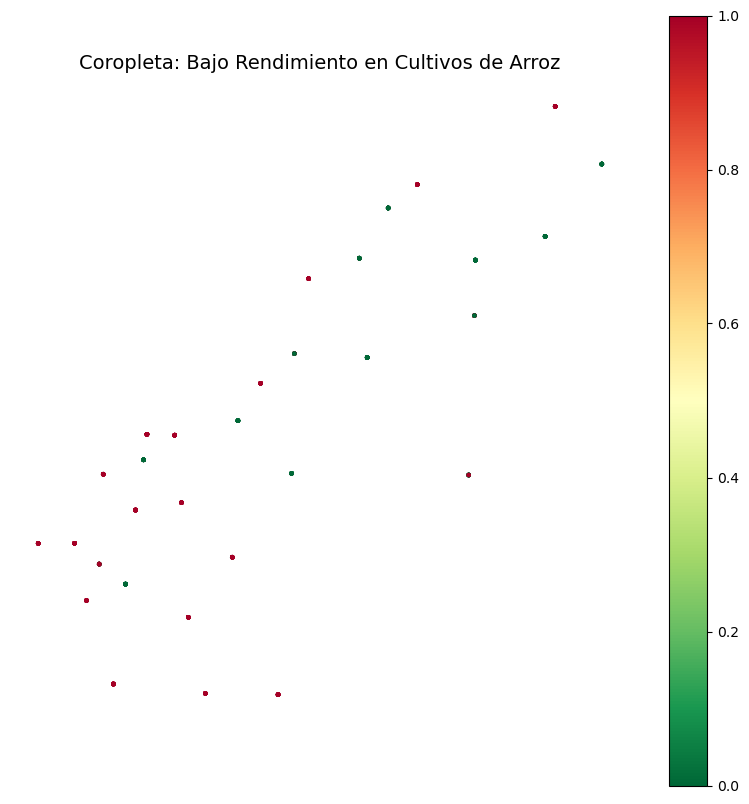

In [6]:
import matplotlib.pyplot as plt

# Coropleta por variable categórica (Bajo_Rendimiento)
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
gdf.plot(column='Bajo_Rendimiento', cmap='RdYlGn_r', legend=True, ax=ax, markersize=5)
ax.set_title("Coropleta: Bajo Rendimiento en Cultivos de Arroz", fontsize=14)
plt.axis('off')
plt.show()


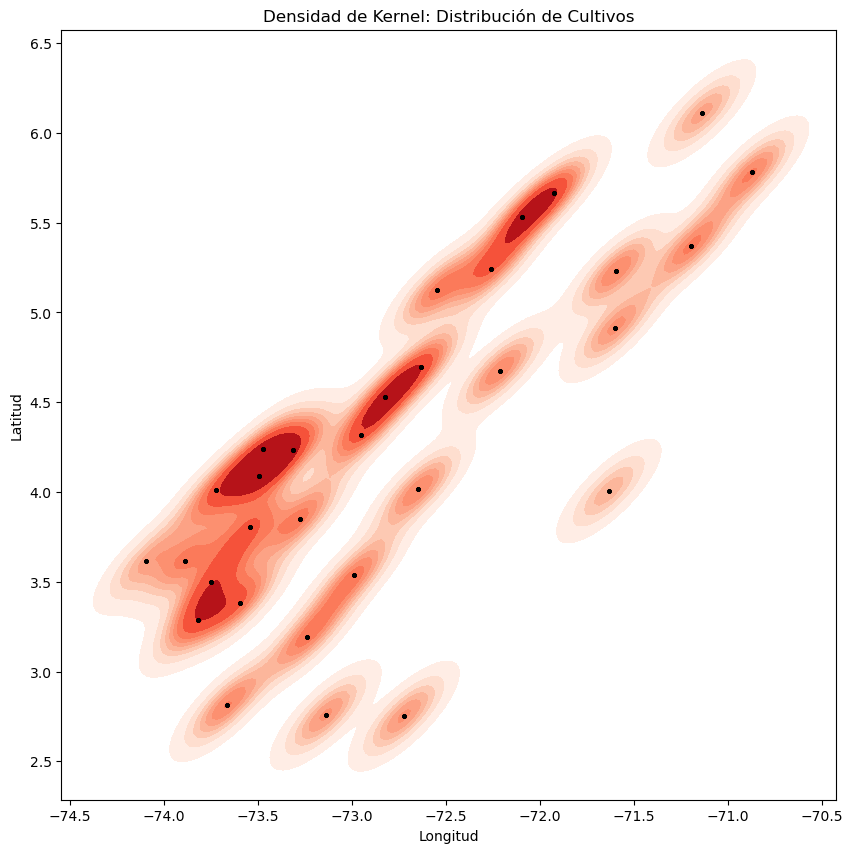

In [7]:
import seaborn as sns

plt.figure(figsize=(10, 10))
sns.kdeplot(
    x=gdf['lon'],
    y=gdf['lat'],
    cmap="Reds",
    fill=True,
    bw_adjust=0.5,
    thresh=0.05
)
plt.scatter(gdf['lon'], gdf['lat'], s=5, color='black', alpha=0.3)
plt.title("Densidad de Kernel: Distribución de Cultivos")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.show()


In [8]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# 1. Cargar base de datos con rendimiento
file_path = r"C:/Users/paola/Analisis Geoespacial/Proyecto_01 - copia/Datos de cultivos/BaseDatosArroz_con_precipitacion_alta_con_coords.xlsx"
df = pd.read_excel(file_path)

# 2. Agrupar rendimiento por municipio
rend_municipio = df.groupby('municipio_fao')['Rend'].mean().reset_index()
rend_municipio.columns = ['NOMBRE', 'RendimientoProm']

# 3. Cargar shapefile de municipios desde geopandas (descarga desde DANE)
gdf_mun = gpd.read_file("https://raw.githubusercontent.com/napedro/data_colombia_geojson/main/municipios_colombia.geojson")

# 4. Unir shapefile con los datos agregados
gdf_mapa = gdf_mun.merge(rend_municipio, on='NOMBRE', how='left')

# 5. Graficar
fig, ax = plt.subplots(figsize=(12, 12))
gdf_mapa.boundary.plot(ax=ax, linewidth=0.5, color='gray')
gdf_mapa.plot(column='RendimientoProm', ax=ax, cmap='YlGnBu', legend=True, missing_kwds={"color": "lightgrey", "label": "Sin datos"})
ax.set_title("Rendimiento promedio de arroz por municipio", fontsize=15)
ax.axis('off')
plt.show()


HTTPError: HTTP Error 404: Not Found